## Valore e Rischio — Punti 1–4.e

7 equity US, portafoglio buy-and-hold con 10% liquidita.
VaR parametrico, storico, Monte Carlo (GBM). Analisi volatilita.

In [1]:
import subprocess, sys, os, glob
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "openpyxl", "arch"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, NullLocator
from scipy import stats
from arch import arch_model

try:
    from IPython import get_ipython
    if get_ipython() is not None:
        from IPython.display import display
    else:
        raise ImportError
except Exception:
    def display(obj): print(obj)

# Parametri
GG_ANNO = 252
ALPHA = 0.05
ORIZZONTE = 1
N_SIM = 50_000
SEED = 42
CAPITALE = 100_000.0
ANNI_FINESTRA = 3
PESO_CASH = 0.10

LAMBDA_EWMA = 0.94
WARMUP_EWMA = 30
ALPHA_CORR = 0.05
SPLIT_OOS = 0.50

finestre_roll = {"1M": 21, "3M": 63, "1Y": 252}

pesi_ticker = {
    "DHR US Equity":  0.10,
    "EW UN Equity":   0.20,
    "HIG US EQUITY":  0.10,
    "NDAQ US EQUITY": 0.10,
    "PANW US EQUITY": 0.10,
    "TDY US EQUITY":  0.10,
    "VRTX US Equity": 0.20,
}

TICKER_SCELTI = list(pesi_ticker.keys())

CARTELLA_FIG = os.path.join("/content" if os.path.isdir("/content") else os.getcwd(), "figures")
SALVA_FIG = True

# --- Stile matplotlib
DIM_FONT = 9
plt.rcParams.update({
    "font.size": DIM_FONT, "axes.titlesize": DIM_FONT + 1, "axes.labelsize": DIM_FONT,
    "xtick.labelsize": DIM_FONT - 1, "ytick.labelsize": DIM_FONT - 1, "legend.fontsize": DIM_FONT - 1,
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
})

# Funzioni di utilita

def nome_breve(t):
    return str(t).replace(" EQUITY", "").replace(" Equity", "").strip()

def salva_fig(fig, nome):
    if not SALVA_FIG:
        return
    os.makedirs(CARTELLA_FIG, exist_ok=True)
    for ext in (".pdf", ".png"):
        path = os.path.join(CARTELLA_FIG, nome + ext)
        fig.savefig(path, dpi=300 if ext == ".png" else None, bbox_inches="tight", facecolor="white")
        print(f"[SAVE] {os.path.abspath(path)}")

def annota_heatmap(ax, dati, fmt="{:.2f}", fontsize=7, color="black", salta_diag=False):
    arr = np.asarray(dati, dtype=float)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            if salta_diag and i == j:
                continue
            if not np.isfinite(arr[i, j]):
                continue
            ax.text(j, i, fmt.format(arr[i, j]), ha="center", va="center",
                    fontsize=fontsize, color=color)

def formato_data(x, pos):
    dt = mdates.num2date(x, tz=None)
    return f"{dt.month:02d}-{dt.year}"

def asse_tempo(ax, rotation=25):
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_major_formatter(FuncFormatter(formato_data))
    ax.xaxis.set_minor_locator(NullLocator())
    plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right")

def formatta_assi(axes, indice_date, fig=None, fontsize=8.0, rotation=25.0):
    if not hasattr(axes, '__iter__'):
        axes = [axes]
    for ax in axes:
        if ax is None:
            continue
        if indice_date is not None and len(indice_date):
            pad = pd.Timedelta(days=7)
            ax.set_xlim(indice_date.min() - pad, indice_date.max() + pad)
        asse_tempo(ax, rotation=rotation)
        ax.tick_params(axis="x", labelbottom=True, labelsize=fontsize)

File trovato: /home/user/risk-management/Business_Case_Valore_Rischio_2026_Light 2.xlsx


Periodo: 2021-07-19 - 2025-11-17
Shape prezzi: (1131, 7)


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
date,,,,,,,
2025-11-11,215.79,85.16,131.17,87.83,218.27,514.91,429.22
2025-11-12,219.40,85.58,132.67,88.77,210.04,519.43,434.19
2025-11-13,221.20,86.11,133.68,87.43,204.77,505.41,434.52
2025-11-14,221.21,86.30,133.85,87.08,205.25,501.23,437.15
2025-11-17,221.21,86.30,133.85,87.08,205.25,501.23,437.15



Rendimenti log (prime righe):


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
date,,,,,,,
2021-07-20,-0.000529,0.035041,0.015359,0.020948,0.029227,0.037846,-0.013593
2021-07-21,-0.013490,-0.004985,0.004482,0.029306,-0.023144,0.013450,-0.001426
2021-07-22,0.032213,0.009479,-0.016588,-0.005058,0.016554,-0.000837,-0.001275
2021-07-23,0.007962,0.021621,-0.002927,0.012973,0.008160,0.008224,0.022598
2021-07-26,-0.003749,-0.004673,0.008595,-0.006306,-0.006580,-0.001505,-0.007861


[SAVE] /home/user/risk-management/figures/p1_prezzi_normalizzati.pdf


[SAVE] /home/user/risk-management/figures/p1_prezzi_normalizzati.png


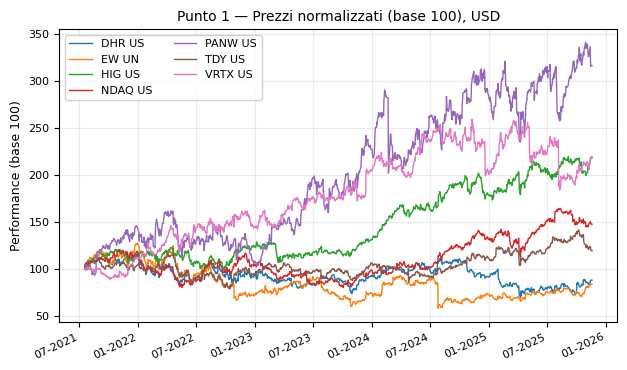

[SAVE] /home/user/risk-management/figures/p1_rendimenti_log.pdf


[SAVE] /home/user/risk-management/figures/p1_rendimenti_log.png


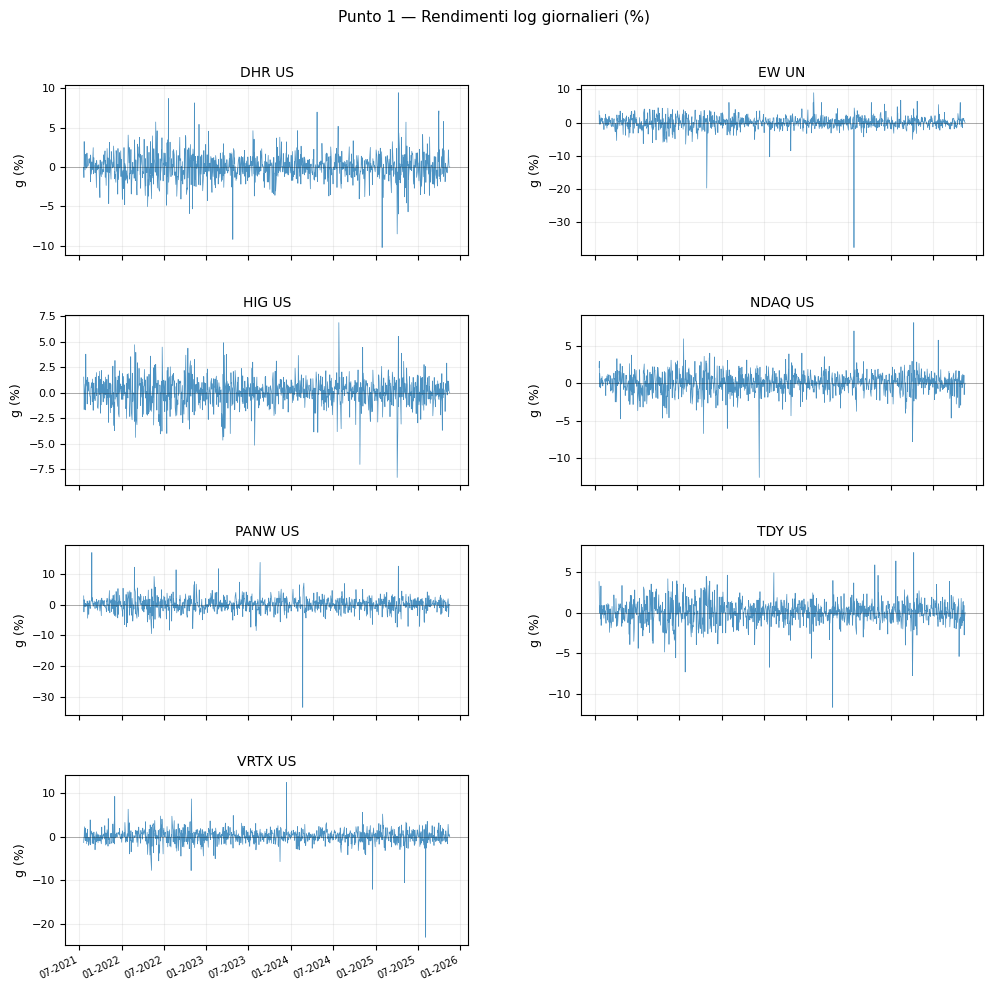

In [2]:
# Punto 1 - Caricamento dati, prezzi normalizzati

def trova_excel():
    nomi = [
        "Business_Case_Valore_Rischio_2026_Light 2.xlsx",
        "Business_Case_Valore_Rischio_2026_Light.xlsx",
        "Business_Case_Valore_Rischio_2026_Light (1).xlsx",
    ]
    radici = []
    if os.path.isdir("/content"):
        radici.append("/content")
    radici.append(os.getcwd())
    try:
        radici.append(os.path.dirname(os.path.abspath(__file__)))
    except NameError:
        pass
    for r in radici:
        for n in nomi:
            p = os.path.join(r, n)
            if os.path.isfile(p):
                return p
        for p in sorted(glob.glob(os.path.join(r, "*Valore_Rischio*Light*.xlsx"))):
            if os.path.isfile(p):
                return p
    raise FileNotFoundError("File Excel non trovato. Caricare in /content/ (Colab) o nella cartella del notebook.")

PERCORSO_EXCEL = trova_excel()
print("File trovato:", PERCORSO_EXCEL)

raw = pd.read_excel(PERCORSO_EXCEL, sheet_name="Prezzi_Equity", header=None)

def riga_header(raw):
    def conta(i):
        riga = raw.iloc[i]
        return sum(1 for j in range(1, raw.shape[1], 2)
                   if isinstance(riga.iloc[j], str) and "EQUITY" in riga.iloc[j].upper())
    return max(range(min(10, len(raw))), key=conta)

riga_h = riga_header(raw)
hdr = raw.iloc[riga_h]

pezzi = []
for j in range(0, raw.shape[1] - 1, 2):
    ticker = hdr.iloc[j + 1]
    if not isinstance(ticker, str) or not ticker.strip():
        continue
    ticker = ticker.strip()
    dcol = raw.iloc[riga_h + 1:, j]
    pcol = raw.iloc[riga_h + 1:, j + 1]
    tmp = pd.DataFrame({
        "date": pd.to_datetime(dcol, errors="coerce"),
        "ticker": ticker,
        "price_usd": pd.to_numeric(pcol, errors="coerce"),
    })
    pezzi.append(tmp)

prezzi_long = pd.concat(pezzi, ignore_index=True).dropna(subset=["date", "price_usd"])
prezzi_long = prezzi_long.sort_values(["ticker", "date"])

pool = set(prezzi_long["ticker"])
def trova_ticker(t, pool):
    if t in pool:
        return t
    up = {k.upper(): k for k in pool}
    return up[t.upper()]

# seleziono solo i ticker US che mi servono
selezionati = [trova_ticker(t, pool) for t in TICKER_SCELTI]

prezzi = (
    prezzi_long[prezzi_long["ticker"].isin(selezionati)]
    .pivot(index="date", columns="ticker", values="price_usd")
    .sort_index()
)
prezzi = prezzi[~prezzi.index.duplicated(keep="last")]
prezzi = prezzi[selezionati]

pesi_azioni = np.array([pesi_ticker[trova_ticker(c, set(pesi_ticker.keys()))] for c in prezzi.columns])
assert np.isclose(pesi_azioni.sum() + PESO_CASH, 1.0)

print(f"Periodo: {prezzi.index.min().date()} - {prezzi.index.max().date()}")
print(f"Shape prezzi: {prezzi.shape}")
display(prezzi.tail())

rend_log = np.log(prezzi / prezzi.shift(1)).dropna(how="all")
print(f"\nRendimenti log (prime righe):")
display(rend_log.head())

# Figura: prezzi normalizzati
px = prezzi.dropna(how="all").ffill()
norm100 = (px / px.iloc[0]) * 100.0

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for col in norm100.columns:
    ax.plot(norm100.index, norm100[col], linewidth=1.0, label=nome_breve(col))
ax.set_title("Punto 1 — Prezzi normalizzati (base 100), USD")
ax.set_ylabel("Performance (base 100)")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, loc="upper left", framealpha=0.9)
asse_tempo(ax)
salva_fig(fig, "p1_prezzi_normalizzati")
plt.show()
plt.close(fig)

# Figura: rendimenti log giornalieri
fig_r, axes_r = plt.subplots(4, 2, figsize=(10.2, 10.0), sharex=True)
axes_r = axes_r.ravel()
for ax_i, col in zip(axes_r, rend_log.columns):
    ax_i.plot(rend_log.index, rend_log[col].values * 100, linewidth=0.5, color="#2c7fb8", alpha=0.85)
    ax_i.axhline(0, color="black", linewidth=0.5, alpha=0.4)
    ax_i.set_title(nome_breve(col), fontsize=10)
    ax_i.set_ylabel("g (%)")
    ax_i.grid(True, alpha=0.2)
axes_r[-1].axis("off")
fig_r.suptitle("Punto 1 — Rendimenti log giornalieri (%)", y=0.995, fontsize=11)
fig_r.subplots_adjust(left=0.08, right=0.98, top=0.92, bottom=0.06, hspace=0.35, wspace=0.28)
for ax_i in axes_r[:-1]:
    if ax_i.get_visible():
        asse_tempo(ax_i, rotation=25)
        ax_i.tick_params(axis="x", labelsize=7)
salva_fig(fig_r, "p1_rendimenti_log")
plt.show()
plt.close(fig_r)

In [3]:
# Punto 2 -- Statistiche, vol rolling, EWMA, GARCH, outlier

rend_lw = rend_log.dropna(how="any").copy()
n_obs_lw = len(rend_lw)

def calcola_riepilogo(prezzi_df, rend_df):
    righe = []
    for col in prezzi_df.columns:
        p = prezzi_df[col].dropna()
        r = rend_df[col].reindex(p.index).dropna()
        p0, pT = p.iloc[0], p.iloc[-1]
        anni = (p.index[-1] - p.index[0]) / np.timedelta64(1, "D") / 365.25
        sig_d = r.std(ddof=1)
        righe.append({
            "ticker": col,
            "n_prezzi": int(len(p)),
            "n_rend": int(len(r)),
            "inizio": p.index.min(),
            "fine": p.index.max(),
            "anni": anni,
            "rend_totale": pT / p0 - 1.0,
            "rend_log_totale": float(np.log(pT / p0)),
            "CAGR": (pT / p0) ** (1 / anni) - 1.0 if anni > 0 else np.nan,
            "media_g": r.mean(),
            "vol_g": sig_d,
            "vol_ann": sig_d * np.sqrt(GG_ANNO),
            "skew": r.skew(),
            "eccesso_kurt": r.kurt(),
            "JB_stat": float(stats.jarque_bera(r.dropna())[0]),
            "JB_pval": float(stats.jarque_bera(r.dropna())[1]),
        })
    return pd.DataFrame(righe).set_index("ticker")

riepilogo = calcola_riepilogo(prezzi, rend_log)

vol_roll_ultima = {}
for nome, w in finestre_roll.items():
    vol_roll_ultima[nome] = (
        rend_log.rolling(window=w, min_periods=w).std(ddof=1) * np.sqrt(GG_ANNO)
    ).iloc[-1]
vol_roll_ultima = pd.DataFrame(vol_roll_ultima).T

print("=== Riepilogo per titolo ===")
display(riepilogo)
print("\n=== Vol rolling ultima osservazione ===")
display(vol_roll_ultima)

# Outlier
SOGLIA_OUTLIER = 0.20
print(f"\n=== Outlier check (|g| > {SOGLIA_OUTLIER:.0%}) ===")
outlier_righe = []
for col in rend_log.columns:
    s = rend_log[col].dropna()
    grandi = s[s.abs() > SOGLIA_OUTLIER]
    for d, v in grandi.items():
        outlier_righe.append({"ticker": col, "data": d.date(), "g": float(v)})
if outlier_righe:
    display(pd.DataFrame(outlier_righe).sort_values("g", key=abs, ascending=False))
else:
    print("Nessun outlier.")

# EWMA RiskMetrics
def vol_ewma_rm(rend, lam=LAMBDA_EWMA, warmup=WARMUP_EWMA):
    r = rend.dropna().astype(float)
    var = np.full(len(r), np.nan)
    if len(r) <= warmup + 1:
        return pd.Series(var, index=r.index)
    var[warmup] = float(np.var(r.iloc[:warmup].values, ddof=1))
    rv = r.values
    for t in range(warmup + 1, len(r)):
        var[t] = lam * var[t - 1] + (1 - lam) * rv[t - 1] ** 2
    return pd.Series(np.sqrt(var) * np.sqrt(GG_ANNO), index=r.index)

vol_ewma = pd.DataFrame({c: vol_ewma_rm(rend_log[c]) for c in rend_log.columns})

# EWMA breve (pandas)
def vol_ewma_breve(rend, span=21):
    r = rend.astype(float)
    v = r.ewm(span=span, adjust=False).var(bias=True)
    return np.sqrt(np.maximum(v, 0.0) * GG_ANNO)

vol_ewma_1m = pd.DataFrame({c: vol_ewma_breve(rend_log[c]) for c in rend_log.columns})

# Modelli vol condizionata
def stima_garch(rend, scala=100.0):
    nome_titolo = rend.name if rend.name else "asset"
    y_raw = rend.dropna().astype(float)
    idx = y_raw.index
    y = (y_raw * scala).rename("y")

    def to_vol(res):
        sigma = pd.Series(res.conditional_volatility, index=idx) / scala
        return sigma * np.sqrt(GG_ANNO)

    def prova_fit(modello):
        try:
            return modello.fit(update_freq=0, disp="off", options={"maxiter": 10000})
        except Exception:
            return None

    def info_modello(res, etichetta):
        p = res.params.to_dict()
        riga = {"modello": etichetta, "AIC": res.aic, "BIC": res.bic, "nu": p.get("nu", np.nan)}
        for k in ["omega", "alpha[1]", "beta[1]", "gamma[1]"]:
            if k in p:
                riga[k] = p[k]
        a = riga.get("alpha[1]", np.nan)
        b = riga.get("beta[1]", np.nan)
        riga["persistenza"] = (float(a) + float(b)) if np.isfinite(a) and np.isfinite(b) else np.nan
        return pd.DataFrame([riga], index=[nome_titolo])

    # 1) GARCH(1,1)-t
    r1 = prova_fit(arch_model(y, mean="Constant", vol="GARCH", p=1, q=1, dist="studentst"))
    if r1 is not None:
        beta = float(r1.params.get("beta[1]", np.nan))
        if np.isfinite(beta) and beta > 1e-4:
            return to_vol(r1), info_modello(r1, "GARCH(1,1)-t")

    # 2) EGARCH(1,1,1)-t
    r2 = prova_fit(arch_model(y, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="studentst"))
    if r2 is not None:
        return to_vol(r2), info_modello(r2, "EGARCH(1,1,1)-t")

    # 3) GARCH(1,1)-N
    r3 = prova_fit(arch_model(y, mean="Constant", vol="GARCH", p=1, q=1, dist="normal"))
    if r3 is not None:
        beta = float(r3.params.get("beta[1]", np.nan))
        if np.isfinite(beta) and beta > 1e-4:
            return to_vol(r3), info_modello(r3, "GARCH(1,1)-N")

    # 4) EGARCH(1,1,1)-N
    r4 = prova_fit(arch_model(y, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="normal"))
    if r4 is not None:
        return to_vol(r4), info_modello(r4, "EGARCH(1,1,1)-N")

    raise RuntimeError(f"Nessun modello ARCH stimabile per {nome_titolo}")

vol_garch = {}
param_garch = []
for c in rend_log.columns:
    v, par = stima_garch(rend_log[c].rename(c))
    vol_garch[c] = v
    param_garch.append(par)

vol_garch = pd.concat(vol_garch, axis=1)
param_garch = pd.concat(param_garch, axis=0)

print("\n=== Modelli vol condizionata ===")
print("Fallback: GARCH-t -> EGARCH-t -> GARCH-N -> EGARCH-N")
display(param_garch)

=== Riepilogo per titolo ===


,n_prezzi,n_rend,inizio,fine,anni,rend_totale,rend_log_totale,CAGR,media_g,vol_g,vol_ann,skew,eccesso_kurt,JB_stat,JB_pval
ticker,,,,,,,,,,,,,,,
DHR US Equity,1131,1130,2021-07-19,2025-11-17,4.33128,-0.120484,-0.128383,-0.029206,-0.000114,0.017469,0.277308,0.016550,4.452154,922.878603,3.976103e-201
EW UN Equity,1131,1130,2021-07-19,2025-11-17,4.33128,-0.161403,-0.176025,-0.039826,-0.000156,0.021815,0.346304,-5.211452,84.057811,334803.143578,0.000000e+00
HIG US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,1.180678,0.779636,0.197219,0.000690,0.013772,0.218630,-0.390157,3.309996,538.246833,1.321859e-117
NDAQ US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,0.474682,0.388443,0.093828,0.000344,0.014638,0.232365,-0.751183,7.649559,2833.005688,0.000000e+00
PANW US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,2.162217,1.151273,0.304480,0.001019,0.026072,0.413877,-1.400988,27.745649,36280.962104,0.000000e+00
TDY US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,0.192666,0.176192,0.041518,0.000156,0.014798,0.234904,-0.620512,6.211503,1869.818995,0.000000e+00
VRTX US Equity,1131,1130,2021-07-19,2025-11-17,4.33128,1.194088,0.785766,0.198915,0.000695,0.017877,0.283794,-2.071557,30.676168,44706.760480,0.000000e+00



=== Vol rolling ultima osservazione ===


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
1M,0.261458,0.236394,0.144369,0.205238,0.244363,0.263851,0.178699
3M,0.315409,0.196487,0.165861,0.200867,0.226642,0.216676,0.197059
1Y,0.325086,0.237917,0.212152,0.235353,0.344975,0.226665,0.363548



=== Outlier check (|g| > 20%) ===


,ticker,data,g
0,EW UN Equity,2024-07-25,-0.376001
1,PANW US EQUITY,2024-02-21,-0.334649
2,VRTX US Equity,2025-08-05,-0.230678



=== Modelli vol condizionata ===
Fallback: GARCH-t -> EGARCH-t -> GARCH-N -> EGARCH-N


,modello,AIC,BIC,nu,omega,alpha[1],beta[1],persistenza
DHR US Equity,"GARCH(1,1)-t",4276.951185,4302.101050,3.976413,0.699482,0.137437,0.654521,0.791958
EW UN Equity,"GARCH(1,1)-t",4413.920446,4439.070310,3.358501,0.564763,0.076704,0.783440,0.860144
HIG US EQUITY,"GARCH(1,1)-t",3764.313193,3789.463058,4.780810,0.273917,0.126244,0.736524,0.862767
NDAQ US EQUITY,"GARCH(1,1)-t",3853.206323,3878.356187,3.995770,0.278866,0.118937,0.763902,0.882838
PANW US EQUITY,"GARCH(1,1)-t",5005.670662,5030.820527,3.346873,2.989830,0.140467,0.424260,0.564727
TDY US EQUITY,"GARCH(1,1)-t",3876.836320,3901.986185,3.828699,0.162836,0.073277,0.859904,0.933181
VRTX US Equity,"GARCH(1,1)-t",4102.525513,4127.675377,3.814766,0.944266,0.173876,0.501410,0.675286


In [4]:
# Punto 2 --- Correlazioni con test t

def correlazioni_test(df, alpha=ALPHA_CORR):
    # Pearson + test H0: rho=0, t = rho*sqrt((n-2)/(1-rho^2))
    x = df.dropna(how="any")
    n = int(len(x))
    R_corr = x.corr(method="pearson")
    cols = list(R_corr.columns)
    gl = n - 2
    P_pval = pd.DataFrame(np.nan, index=R_corr.index, columns=R_corr.columns)
    T_stat = pd.DataFrame(np.nan, index=R_corr.index, columns=R_corr.columns)

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            rho = float(R_corr.iloc[i, j])
            den = max(1e-12, 1 - rho ** 2)
            t_val = rho * np.sqrt(gl / den)
            p_val = float(2 * (1 - stats.t.cdf(abs(t_val), df=gl)))
            T_stat.iloc[i, j] = T_stat.iloc[j, i] = t_val
            P_pval.iloc[i, j] = P_pval.iloc[j, i] = p_val

    return R_corr, P_pval, T_stat

R_corr, P_pval, T_stat = correlazioni_test(rend_lw, ALPHA_CORR)

# Tabella coppie
cols = list(R_corr.columns)
righe_coppie = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        p_ij = float(P_pval.iloc[i, j])
        righe_coppie.append({
            "titolo_i": cols[i], "titolo_j": cols[j],
            "rho": float(R_corr.iloc[i, j]),
            "t_stat": float(T_stat.iloc[i, j]),
            "p_value": p_ij,
            "significativo": p_ij < ALPHA_CORR,
        })
tabella_coppie = pd.DataFrame(righe_coppie)
n_sig = int(tabella_coppie["significativo"].sum())
n_tot = len(tabella_coppie)

print(f"Listwise n={n_obs_lw}, alpha={ALPHA_CORR}")
print(f"Coppie significative: {n_sig}/{n_tot}")
display(R_corr.round(3))
display(tabella_coppie.round(4))

vol_roll_1Y = rend_log.rolling(window=finestre_roll["1Y"], min_periods=finestre_roll["1Y"]).std(ddof=1) * np.sqrt(GG_ANNO)

Listwise n=1130, alpha=0.05
Coppie significative: 21/21


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
ticker,,,,,,,
DHR US Equity,1.000,0.318,0.301,0.445,0.295,0.419,0.276
EW UN Equity,0.318,1.000,0.204,0.251,0.252,0.298,0.142
HIG US EQUITY,0.301,0.204,1.000,0.393,0.168,0.448,0.195
NDAQ US EQUITY,0.445,0.251,0.393,1.000,0.320,0.460,0.228
PANW US EQUITY,0.295,0.252,0.168,0.320,1.000,0.317,0.192
TDY US EQUITY,0.419,0.298,0.448,0.460,0.317,1.000,0.231
VRTX US Equity,0.276,0.142,0.195,0.228,0.192,0.231,1.000


,titolo_i,titolo_j,rho,t_stat,p_value,significativo
0,DHR US Equity,EW UN Equity,0.3181,11.2679,0.0,True
1,DHR US Equity,HIG US EQUITY,0.3014,10.6178,0.0,True
2,DHR US Equity,NDAQ US EQUITY,0.4445,16.6670,0.0,True
3,DHR US Equity,PANW US EQUITY,0.2945,10.3518,0.0,True
4,DHR US Equity,TDY US EQUITY,0.4189,15.4947,0.0,True
5,DHR US Equity,VRTX US Equity,0.2756,9.6295,0.0,True
6,EW UN Equity,HIG US EQUITY,0.2041,7.0033,0.0,True
7,EW UN Equity,NDAQ US EQUITY,0.2509,8.7050,0.0,True
8,EW UN Equity,PANW US EQUITY,0.2520,8.7446,0.0,True
9,EW UN Equity,TDY US EQUITY,0.2980,10.4867,0.0,True


[SAVE] /home/user/risk-management/figures/p2_rendimenti.pdf


[SAVE] /home/user/risk-management/figures/p2_rendimenti.png


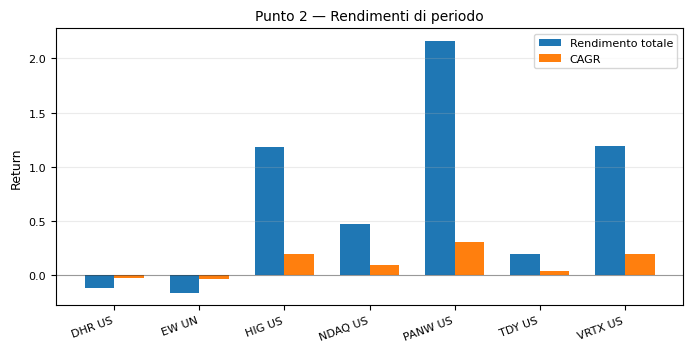

[SAVE] /home/user/risk-management/figures/p2_vol_statica_vs_roll1y.pdf


[SAVE] /home/user/risk-management/figures/p2_vol_statica_vs_roll1y.png


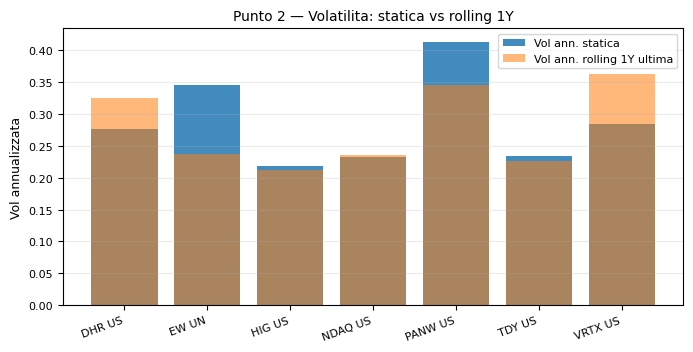

[SAVE] /home/user/risk-management/figures/p2_heatmap_rho.pdf


[SAVE] /home/user/risk-management/figures/p2_heatmap_rho.png


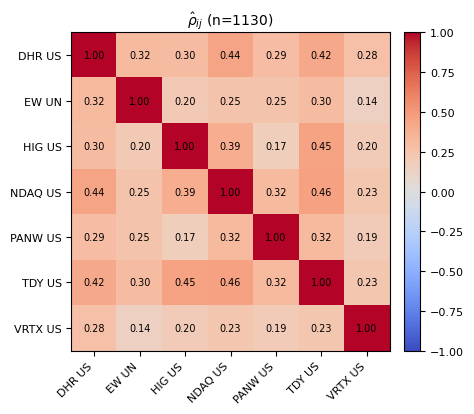

[SAVE] /home/user/risk-management/figures/p2_heatmap_pval.pdf


[SAVE] /home/user/risk-management/figures/p2_heatmap_pval.png


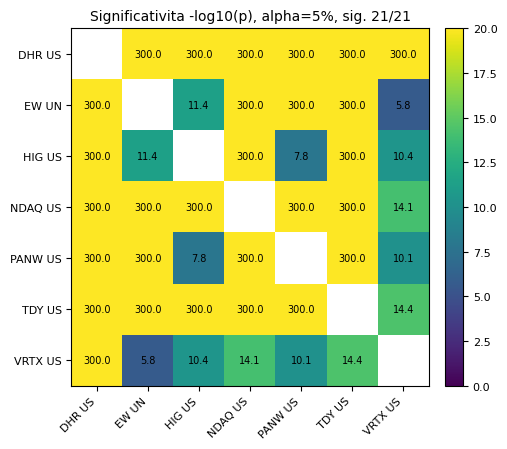

[SAVE] /home/user/risk-management/figures/p2_vol_pannelli.pdf


[SAVE] /home/user/risk-management/figures/p2_vol_pannelli.png


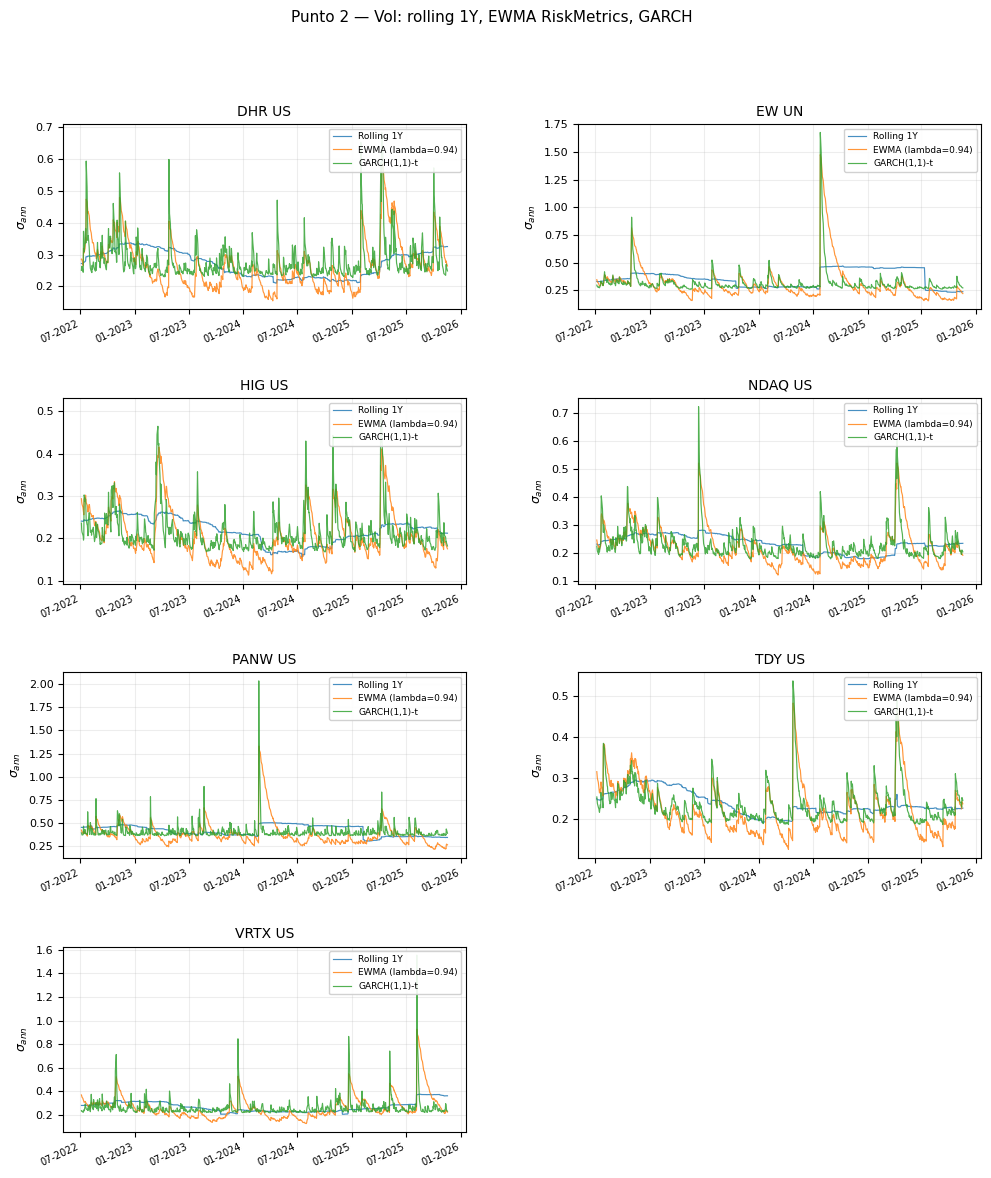

In [5]:
# Punto 2 — Figure

# barre rendimenti e CAGR
fig, ax = plt.subplots(figsize=(7.0, 3.6))
x = np.arange(len(riepilogo))
w = 0.35
ax.bar(x - w/2, riepilogo["rend_totale"].values, width=w, label="Rendimento totale")
ax.bar(x + w/2, riepilogo["CAGR"].values, width=w, label="CAGR")
ax.set_xticks(x)
ax.set_xticklabels([nome_breve(t) for t in riepilogo.index], rotation=20, ha="right")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.35)
ax.set_title("Punto 2 — Rendimenti di periodo")
ax.set_ylabel("Return")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
salva_fig(fig, "p2_rendimenti")
plt.show()
plt.close(fig)

# vol statica vs rolling 1Y
fig, ax = plt.subplots(figsize=(7.0, 3.6))
lbl = [nome_breve(t) for t in riepilogo.index]
ax.bar(lbl, riepilogo["vol_ann"].values, alpha=0.85, label="Vol ann. statica")
ax.bar(lbl, vol_roll_ultima.loc["1Y"].reindex(riepilogo.index).values, alpha=0.55, label="Vol ann. rolling 1Y ultima")
ax.set_title("Punto 2 — Volatilita: statica vs rolling 1Y")
ax.set_ylabel("Vol annualizzata")
plt.xticks(rotation=20, ha="right")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
salva_fig(fig, "p2_vol_statica_vs_roll1y")
plt.show()
plt.close(fig)

# heatmap rho
lbl_c = [nome_breve(c) for c in R_corr.columns]
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(R_corr.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(np.arange(len(lbl_c)))
ax.set_yticks(np.arange(len(lbl_c)))
ax.set_xticklabels(lbl_c, rotation=45, ha="right")
ax.set_yticklabels(lbl_c)
ax.set_title(f"$\\hat\\rho_{{ij}}$ (n={n_obs_lw})")
annota_heatmap(ax, R_corr.values, fmt="{:.2f}")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(pad=1.0)
salva_fig(fig, "p2_heatmap_rho")
plt.show()
plt.close(fig)

# heatmap significativita
Pv = P_pval.values.astype(float).copy()
np.fill_diagonal(Pv, np.nan)
with np.errstate(divide="ignore", invalid="ignore"):
    Z = -np.log10(np.clip(Pv, 1e-300, 1.0))
np.fill_diagonal(Z, np.nan)
Z_plot = np.ma.masked_invalid(Z)
zmax = min(max(float(np.percentile(Z_plot.compressed(), 99)) if Z_plot.compressed().size else 3.0, 3.0), 20.0)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(Z_plot, cmap="viridis", vmin=0.0, vmax=zmax)
ax.set_xticks(np.arange(len(lbl_c)))
ax.set_yticks(np.arange(len(lbl_c)))
ax.set_xticklabels(lbl_c, rotation=45, ha="right")
ax.set_yticklabels(lbl_c)
ax.set_title(f"Significativita -log10(p), alpha={ALPHA_CORR:.0%}, sig. {n_sig}/{n_tot}")
annota_heatmap(ax, Z_plot, fmt="{:.1f}", salta_diag=True)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout(pad=1.2)
salva_fig(fig, "p2_heatmap_pval")
plt.show()
plt.close(fig)

# pannelli vol overlay (rolling 1Y + EWMA + GARCH)
fig, axes = plt.subplots(4, 2, figsize=(10.2, 12.0), sharex=False)
axes = axes.ravel()
for ax_i, col in zip(axes, rend_log.columns):
    r1 = vol_roll_1Y[col].dropna()
    e1 = vol_ewma[col].reindex(r1.index).dropna()
    g1 = vol_garch[col].reindex(r1.index).dropna()
    kw = {"linewidth": 0.85, "alpha": 0.82}
    ax_i.plot(r1.index, r1.values, color="#1f77b4", label="Rolling 1Y", **kw)
    ax_i.plot(e1.index, e1.values, color="#ff7f0e", label=f"EWMA (lambda={LAMBDA_EWMA})", **kw)
    mod_lbl = param_garch.loc[col, "modello"] if col in param_garch.index else "GARCH"
    ax_i.plot(g1.index, g1.values, color="#2ca02c", label=mod_lbl, **kw)
    ax_i.set_title(nome_breve(col), fontsize=10)
    ax_i.set_ylabel(r"$\sigma_{ann}$")
    ax_i.grid(True, alpha=0.22)
    ax_i.legend(fontsize=6.5, loc="upper right", framealpha=0.9)

axes[-1].axis("off")
fig.suptitle("Punto 2 — Vol: rolling 1Y, EWMA RiskMetrics, GARCH", y=0.995, fontsize=11)
fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.06, hspace=0.48, wspace=0.28)
for ax_i in axes[:-1]:
    if ax_i.get_visible():
        asse_tempo(ax_i, rotation=25)
        ax_i.tick_params(axis="x", labelsize=7)
salva_fig(fig, "p2_vol_pannelli")
plt.show()
plt.close(fig)

=== Punto 3 — VaR (magnitudine positiva su log-rendimento) ===
alpha=0.05, H=1g, MC N=50000, seed=42


,var_parametrico (%),var_storico (%),var_mc_gbm (%)
ticker,,,
DHR US Equity,2.8847,2.7151,2.8924
EW UN Equity,3.6038,2.7305,3.5937
HIG US EQUITY,2.1964,2.1990,2.2019
NDAQ US EQUITY,2.3733,2.2936,2.3604
PANW US EQUITY,4.1865,3.7980,4.1737
TDY US EQUITY,2.4184,2.3111,2.4323
VRTX US Equity,2.8710,2.3530,2.8589


,var_parametrico (USD),var_storico (USD),var_mc_gbm (USD)
ticker,,,
DHR US Equity,2843.50,2678.53,2850.98
EW UN Equity,3539.68,2693.54,3529.92
HIG US EQUITY,2172.42,2174.95,2177.84
NDAQ US EQUITY,2345.36,2267.49,2332.75
PANW US EQUITY,4100.12,3726.76,4087.82
TDY US EQUITY,2389.38,2284.59,2402.92
VRTX US Equity,2830.20,2325.54,2818.39



=== Parametri GBM per titolo ===
  DHR US        mu_ann=0.009819  sigma_ann=0.2773  drift_gg=-0.000114  diff_gg=0.017469
  EW UN         mu_ann=0.020708  sigma_ann=0.3463  drift_gg=-0.000156  diff_gg=0.021815
  HIG US        mu_ann=0.197765  sigma_ann=0.2186  drift_gg=0.000690  diff_gg=0.013772
  NDAQ US       mu_ann=0.113623  sigma_ann=0.2324  drift_gg=0.000344  diff_gg=0.014638
  PANW US       mu_ann=0.342391  sigma_ann=0.4139  drift_gg=0.001019  diff_gg=0.026072
  TDY US        mu_ann=0.066882  sigma_ann=0.2349  drift_gg=0.000156  diff_gg=0.014798
  VRTX US       mu_ann=0.215502  sigma_ann=0.2838  drift_gg=0.000695  diff_gg=0.017877

=== Violazioni OOS ===


,parametrico,storico,mc_gbm
ticker,,,
DHR US Equity,0.0407,0.0442,0.0407
EW UN Equity,0.0071,0.0071,0.0071
HIG US EQUITY,0.0283,0.0301,0.0283
NDAQ US EQUITY,0.0265,0.0283,0.0265
PANW US EQUITY,0.0301,0.0336,0.0265
TDY US EQUITY,0.0265,0.0265,0.0248
VRTX US Equity,0.0372,0.0513,0.0372


[SAVE] /home/user/risk-management/figures/p3_var_e_violazioni.pdf


[SAVE] /home/user/risk-management/figures/p3_var_e_violazioni.png


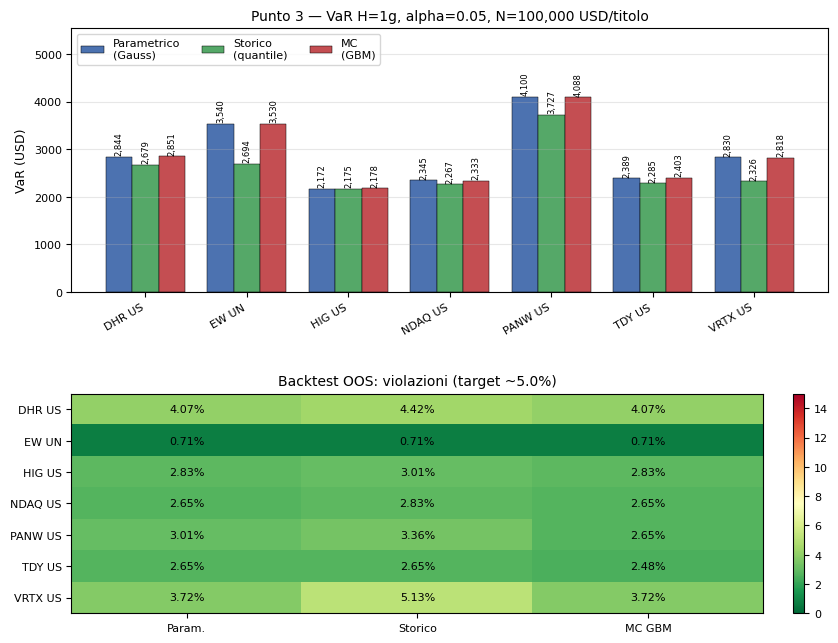

In [6]:
# --- Punto 3 - VaR singoli titoli: parametrico, storico, MC GBM

def var_parametrico(g, alpha=ALPHA, orizzonte=ORIZZONTE):
    g = g.dropna().astype(float)
    mu = float(g.mean())
    sigma = float(g.std(ddof=1))
    z = float(stats.norm.ppf(alpha))
    if orizzonte == 1:
        return float(-(mu + sigma * z))
    return float(-(orizzonte * mu + np.sqrt(orizzonte) * sigma * z))

def var_storico(g, alpha=ALPHA, orizzonte=ORIZZONTE):
    g = g.dropna().astype(float)
    if orizzonte > 1:
        g = g.rolling(orizzonte, min_periods=orizzonte).sum().dropna()
    return float(-np.quantile(g, alpha))

def var_mc_gbm(g, alpha=ALPHA, orizzonte=ORIZZONTE, n_sim=N_SIM, rng=None):
    # MC via Geometric Brownian Motion esplicito
    g = g.dropna().astype(float)
    if rng is None:
        rng = np.random.default_rng(SEED)

    dt = 1.0 / GG_ANNO
    mu_hat = float(g.mean())
    sigma_hat = float(g.std(ddof=1))

    # Annualizzazione GBM
    sigma_ann = sigma_hat * np.sqrt(GG_ANNO)
    mu_ann = mu_hat * GG_ANNO + sigma_ann ** 2 / 2

    drift = (mu_ann - sigma_ann ** 2 / 2) * dt
    diffusione = sigma_ann * np.sqrt(dt)

    if orizzonte == 1:
        Z = rng.standard_normal(n_sim)
        g_sim = drift + diffusione * Z
    else:
        g_sim = np.zeros(n_sim)
        for _ in range(orizzonte):
            Z = rng.standard_normal(n_sim)
            g_sim += drift + diffusione * Z

    return float(-np.quantile(g_sim, alpha))

def calcola_var_titoli(rend):
    righe = []
    for j, col in enumerate(rend.columns):
        rng_j = np.random.default_rng(SEED + j * 1009)
        s = rend[col]
        righe.append({
            "ticker": col,
            "var_parametrico": var_parametrico(s),
            "var_storico": var_storico(s),
            "var_mc_gbm": var_mc_gbm(s, rng=rng_j),
        })
    return pd.DataFrame(righe).set_index("ticker")

def var_in_usd(var_g, capitale=CAPITALE):
    return capitale * (1 - np.exp(-var_g.astype(float)))

tabella_var = calcola_var_titoli(rend_log)
tabella_var_usd = var_in_usd(tabella_var)

print("=== Punto 3 — VaR (magnitudine positiva su log-rendimento) ===")
print(f"alpha={ALPHA}, H={ORIZZONTE}g, MC N={N_SIM}, seed={SEED}")
display((tabella_var * 100).round(4).rename(columns=lambda c: c + " (%)"))
display(tabella_var_usd.round(2).rename(columns=lambda c: c + " (USD)"))

# Stampa parametri GBM per ogni titolo
print("\n=== Parametri GBM per titolo ===")
for col in rend_log.columns:
    g = rend_log[col].dropna().astype(float)
    mu_hat = float(g.mean())
    sigma_hat = float(g.std(ddof=1))
    sigma_ann = sigma_hat * np.sqrt(GG_ANNO)
    mu_ann = mu_hat * GG_ANNO + sigma_ann ** 2 / 2
    dt = 1.0 / GG_ANNO
    drift = (mu_ann - sigma_ann ** 2 / 2) * dt
    diff = sigma_ann * np.sqrt(dt)
    print(f"  {nome_breve(col):12s}  mu_ann={mu_ann:.6f}  sigma_ann={sigma_ann:.4f}  "
          f"drift_gg={drift:.6f}  diff_gg={diff:.6f}")

# Backtest OOS
def var_su_train(g, metodo, rng):
    g = g.dropna().astype(float)
    split = int(len(g) * SPLIT_OOS)
    g_train = g.iloc[:split]
    if metodo == "parametrico":
        return var_parametrico(g_train)
    elif metodo == "storico":
        return var_storico(g_train)
    else:
        return var_mc_gbm(g_train, rng=rng)

violazioni_oos = pd.DataFrame(
    index=rend_log.columns,
    columns=["parametrico", "storico", "mc_gbm"],
    dtype=float,
)
for j, col in enumerate(rend_log.columns):
    rng_c = np.random.default_rng(SEED + 17_000 + j)
    g = rend_log[col].dropna().astype(float)
    split = int(len(g) * SPLIT_OOS)
    g_test = g.iloc[split:]
    perdita_test = -g_test

    for met, chiave in [("parametrico", "parametrico"), ("storico", "storico"), ("mc_gbm", "mc_gbm")]:
        v_tr = var_su_train(g, met, rng_c)
        violazioni_oos.loc[col, chiave] = float((perdita_test > v_tr).mean())

print("\n=== Violazioni OOS ===")
display(violazioni_oos.round(4))

# Figura: barre VaR USD + heatmap violazioni
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(8.6, 6.8),
    gridspec_kw={"height_ratios": [1.2, 1.0], "hspace": 0.42})

metodi = ["var_parametrico", "var_storico", "var_mc_gbm"]
etichette_m = ["Parametrico\n(Gauss)", "Storico\n(quantile)", "MC\n(GBM)"]
colori_m = ["#4C72B0", "#55A868", "#C44E52"]
x = np.arange(len(tabella_var))
w = 0.26
for i, (m, lab, c) in enumerate(zip(metodi, etichette_m, colori_m)):
    vals = tabella_var_usd[m].values.astype(float)
    barre = ax_a.bar(x + (i - 1) * w, vals, width=w, label=lab, color=c, edgecolor="black", linewidth=0.35)
    for b, val in zip(barre, vals):
        if np.isfinite(val):
            ax_a.text(b.get_x() + b.get_width() / 2, b.get_height() + 30,
                      f"{val:,.0f}", ha="center", va="bottom", fontsize=6, rotation=90)

ax_a.set_xticks(x)
ax_a.set_xticklabels([nome_breve(t) for t in tabella_var.index], rotation=30, ha="right")
ax_a.set_ylabel("VaR (USD)")
ax_a.set_title(f"Punto 3 — VaR H={ORIZZONTE}g, alpha={ALPHA}, N={CAPITALE:,.0f} USD/titolo")
ax_a.grid(True, axis="y", alpha=0.3)
ax_a.legend(fontsize=8, ncol=3, loc="upper left")
ymax = float(np.nanmax(tabella_var_usd.values)) * 1.35
ax_a.set_ylim(0, ymax)

Zv = (violazioni_oos.values.astype(float) * 100)
im = ax_b.imshow(Zv, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=max(100 * ALPHA * 3, 15))
ax_b.set_xticks(np.arange(3))
ax_b.set_yticks(np.arange(len(violazioni_oos)))
ax_b.set_xticklabels(["Param.", "Storico", "MC GBM"])
ax_b.set_yticklabels([nome_breve(t) for t in violazioni_oos.index])
ax_b.set_title(f"Backtest OOS: violazioni (target ~{100*ALPHA:.1f}%)")
for i in range(Zv.shape[0]):
    for j in range(Zv.shape[1]):
        ax_b.text(j, i, f"{Zv[i,j]:.2f}%", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax_b, fraction=0.046, pad=0.04)
fig.subplots_adjust(left=0.08, right=0.96, top=0.96, bottom=0.10, hspace=0.45)
salva_fig(fig, "p3_var_e_violazioni")
plt.show()
plt.close(fig)

=== Punto 4.a — Portafoglio ===
t0: 2022-11-17, t_fine: 2025-11-17, osservazioni: 783


,ticker,peso
0,DHR US Equity,0.1
1,EW UN Equity,0.2
2,HIG US EQUITY,0.1
3,NDAQ US EQUITY,0.1
4,PANW US EQUITY,0.1
5,TDY US EQUITY,0.1
6,VRTX US Equity,0.2
7,Liquidita,0.1



=== Punto 4.b ===
n_g=782, ret totale log=0.3477, simple=0.4158
vol giornaliera=0.009562, vol ann.=0.1518


[SAVE] /home/user/risk-management/figures/p4a_portafoglio.pdf


[SAVE] /home/user/risk-management/figures/p4a_portafoglio.png


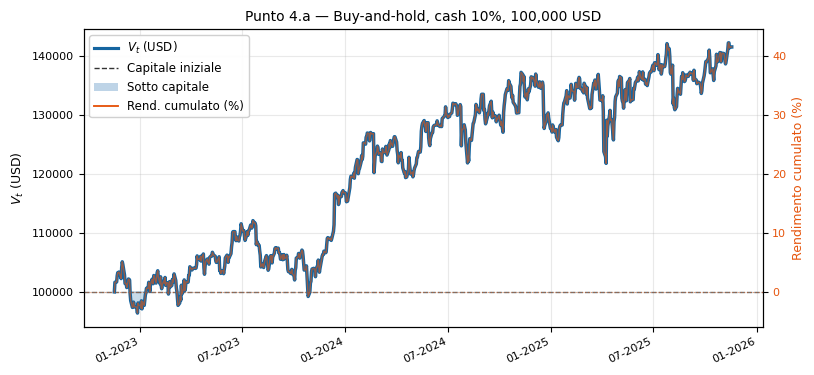

[SAVE] /home/user/risk-management/figures/p4b_rendimenti_vol.pdf


[SAVE] /home/user/risk-management/figures/p4b_rendimenti_vol.png


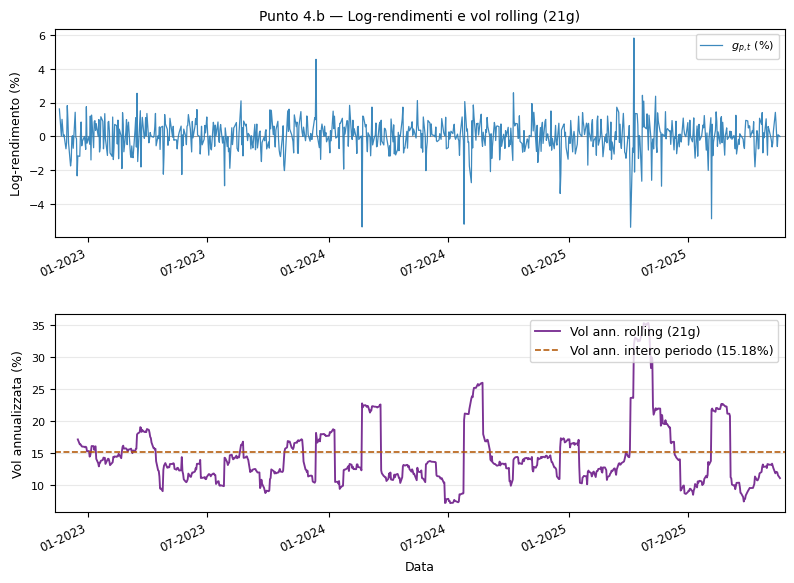

In [7]:
# Punto 4.a - Valore portafoglio (pesi costanti, buy-and-hold)
# Punto 4.b - Log-rendimenti e vol rolling

def valore_portafoglio(prezzi_df, pesi, peso_cash, capitale, anni):
    fine = prezzi_df.index.max()
    t0 = fine - pd.DateOffset(years=anni)
    sub = prezzi_df.loc[prezzi_df.index >= t0].copy().sort_index().ffill().dropna()
    t0_eff = sub.index[0]
    P0 = sub.iloc[0].astype(float)
    rel = sub.astype(float).div(P0, axis=1)
    w = pd.Series(pesi, index=sub.columns)
    V = capitale * (rel.mul(w, axis=1).sum(axis=1) + peso_cash)
    return V.rename("V_ptf"), t0_eff, sub.index.max()

V_ptf, t0_ptf, t_fine_ptf = valore_portafoglio(prezzi, pesi_azioni, PESO_CASH, CAPITALE, ANNI_FINESTRA)

print(f"=== Punto 4.a — Portafoglio ===")
print(f"t0: {t0_ptf.date()}, t_fine: {t_fine_ptf.date()}, osservazioni: {len(V_ptf)}")

w_tab = pd.concat([
    pd.DataFrame({"ticker": list(prezzi.columns), "peso": pesi_azioni}),
    pd.DataFrame({"ticker": ["Liquidita"], "peso": [PESO_CASH]}),
], ignore_index=True)
display(w_tab)

g_ptf = np.log(V_ptf / V_ptf.shift(1)).dropna().astype(float)
g_ptf.name = "g_ptf"
vol_roll_ptf = g_ptf.rolling(21, min_periods=21).std(ddof=1) * np.sqrt(GG_ANNO)

sigma_ptf = float(g_ptf.std(ddof=1))
sigma_ptf_ann = sigma_ptf * np.sqrt(GG_ANNO)
mu_ptf = float(g_ptf.mean())
ret_tot_log = float(np.log(V_ptf.iloc[-1] / V_ptf.iloc[0]))
ret_tot = float(V_ptf.iloc[-1] / V_ptf.iloc[0] - 1)

print(f"\n=== Punto 4.b ===")
print(f"n_g={len(g_ptf)}, ret totale log={ret_tot_log:.4f}, simple={ret_tot:.4f}")
print(f"vol giornaliera={sigma_ptf:.6f}, vol ann.={sigma_ptf_ann:.4f}")

# Figura 4.a: valore portafoglio
pct_da_inizio = (V_ptf / V_ptf.iloc[0] - 1) * 100

fig, ax_v = plt.subplots(figsize=(8.2, 3.8))
ax_r = ax_v.twinx()
ax_v.fill_between(V_ptf.index, CAPITALE, V_ptf.values,
                   where=V_ptf.values < CAPITALE, color="#b3cde3", alpha=0.72, interpolate=True)
ax_v.plot(V_ptf.index, V_ptf.values, color="#1565a0", linewidth=2.5, zorder=5)
ax_v.axhline(CAPITALE, color="#333", linestyle="--", linewidth=1.0, alpha=0.65)
ax_r.plot(V_ptf.index, pct_da_inizio.values, color="#e6550d", linewidth=1.0, alpha=0.6, zorder=2)
ax_r.axhline(0, color="#e6550d", linestyle=":", linewidth=0.8, alpha=0.5)
ax_v.set_ylabel("$V_t$ (USD)")
ax_r.set_ylabel("Rendimento cumulato (%)", color="#e6550d")
ax_r.tick_params(axis="y", labelcolor="#e6550d")
ax_v.set_title(f"Punto 4.a — Buy-and-hold, cash {100*PESO_CASH:.0f}%, {CAPITALE:,.0f} USD")
ax_v.grid(True, alpha=0.28)
asse_tempo(ax_v)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legenda = [
    Line2D([0],[0], color="#1565a0", linewidth=2.25, label="$V_t$ (USD)"),
    Line2D([0],[0], color="#333", linestyle="--", linewidth=1, label="Capitale iniziale"),
    Patch(facecolor="#b3cde3", alpha=0.85, label="Sotto capitale"),
    Line2D([0],[0], color="#e6550d", linewidth=1.35, label="Rend. cumulato (%)"),
]
ax_v.legend(handles=legenda, loc="upper left", fontsize=8.5, framealpha=0.92)
fig.tight_layout(pad=1.0)
salva_fig(fig, "p4a_portafoglio")
plt.show()
plt.close(fig)

# Figura 4.b: log-rendimenti + vol rolling
fig, (ax_g, ax_sv) = plt.subplots(2, 1, figsize=(8.2, 6.2), sharex=False,
    gridspec_kw={"height_ratios": [1.05, 1.0], "hspace": 0.38})

ax_g.axhline(0, color="black", linewidth=0.75, alpha=0.35)
ax_g.plot(g_ptf.index, g_ptf.values * 100, color="#2c7fb8", linewidth=0.9, alpha=0.92, label="$g_{p,t}$ (%)")
ax_g.set_ylabel("Log-rendimento (%)")
ax_g.set_title("Punto 4.b — Log-rendimenti e vol rolling (21g)")
ax_g.grid(True, axis="y", alpha=0.28)
ax_g.legend(loc="upper right", fontsize=8)

ax_sv.plot(vol_roll_ptf.index, vol_roll_ptf.values * 100, color="#7b3294", linewidth=1.35,
           label="Vol ann. rolling (21g)")
ax_sv.axhline(sigma_ptf_ann * 100, color="#b35806", linestyle="--", linewidth=1.15,
              label=f"Vol ann. intero periodo ({sigma_ptf_ann*100:.2f}%)")
ax_sv.set_ylabel("Vol annualizzata (%)")
ax_sv.set_xlabel("Data")
ax_sv.grid(True, axis="y", alpha=0.28)
ax_sv.legend(loc="upper right", fontsize=9)

fig.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.14, hspace=0.42)
formatta_assi((ax_g, ax_sv), g_ptf.index, fontsize=8.5)
salva_fig(fig, "p4b_rendimenti_vol")
plt.show()
plt.close(fig)

=== Punto 4.c — VaR portafoglio ===
N=100,000 USD, alpha=0.05, H=1g, n=783


,var_g,var_usd,mu_p_gg,sigma_p_gg
parametrico,0.014779,1467.007381,0.000379,0.009215
mc_gbm,0.014718,1460.988935,0.000379,0.009215
storico,0.013473,1338.289194,NaN,NaN



=== Parametri GBM multivariato (per asset) ===
  DHR US        mu_ann=0.014442  sigma_ann=0.2652  drift_gg=-0.000082  diff_gg=0.016706
  EW UN         mu_ann=0.101413  sigma_ann=0.3358  drift_gg=0.000179  diff_gg=0.021152
  HIG US        mu_ann=0.216739  sigma_ann=0.2056  drift_gg=0.000776  diff_gg=0.012951
  NDAQ US       mu_ann=0.117359  sigma_ann=0.2237  drift_gg=0.000366  diff_gg=0.014091
  PANW US       mu_ann=0.383272  sigma_ann=0.3955  drift_gg=0.001211  diff_gg=0.024912
  TDY US        mu_ann=0.085227  sigma_ann=0.2196  drift_gg=0.000243  diff_gg=0.013831
  VRTX US       mu_ann=0.154232  sigma_ann=0.2787  drift_gg=0.000458  diff_gg=0.017558


[SAVE] /home/user/risk-management/figures/p4c_var_ptf.pdf


[SAVE] /home/user/risk-management/figures/p4c_var_ptf.png


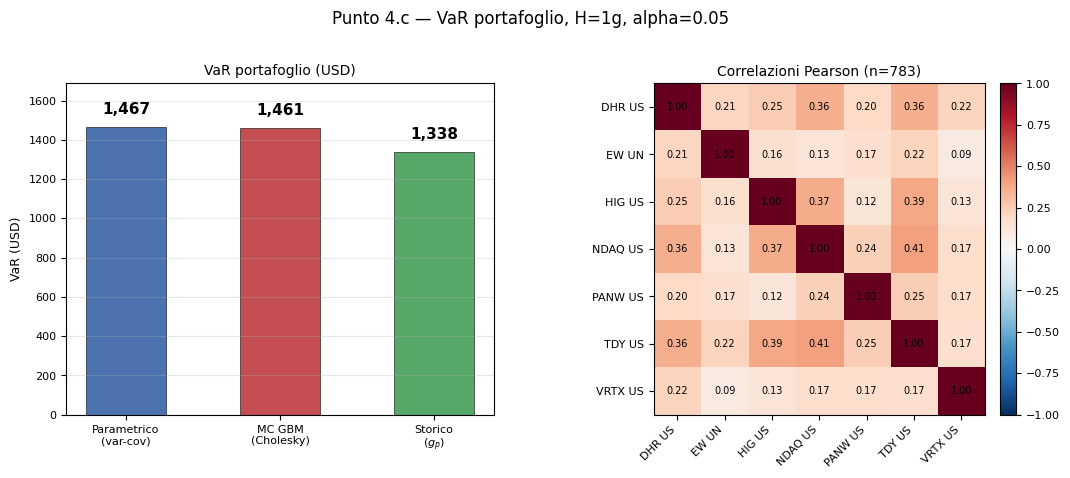

In [8]:
# Punto 4.c -- VaR portafoglio: parametrico, MC GBM multivariato, storico

rend_ptf_finestra = rend_log.loc[rend_log.index >= t0_ptf].dropna(how="any")
n_obs_ptf = int(len(rend_ptf_finestra))

# Parametrico
def var_ptf_parametrico(rend, pesi, alpha=ALPHA, orizzonte=ORIZZONTE):
    x = rend.dropna(how="any").astype(float)
    w = np.asarray(pesi, dtype=float)
    mu_vec = x.mean().values
    Sigma = x.cov(ddof=1)
    mu_p = float(w @ mu_vec)
    sigma_p = float(np.sqrt(w @ Sigma.values @ w))
    z = float(stats.norm.ppf(alpha))
    if orizzonte == 1:
        q = mu_p + sigma_p * z
    else:
        q = orizzonte * mu_p + np.sqrt(orizzonte) * sigma_p * z
    return float(-q), mu_p, sigma_p, Sigma, x.corr()

var_g_param, mu_p, sigma_p, Sigma_ptf, Corr_ptf = var_ptf_parametrico(rend_ptf_finestra, pesi_azioni)

# MC GBM multivariato con Cholesky
def var_ptf_mc_gbm(rend, pesi, alpha=ALPHA, orizzonte=ORIZZONTE, n_sim=N_SIM, rng=None):
    # MC multivariato via GBM: Cholesky sulla matrice di correlazione
    x = rend.dropna(how="any").astype(float)
    w = np.asarray(pesi, dtype=float)
    n_asset = x.shape[1]

    if rng is None:
        rng = np.random.default_rng(SEED + 9031)

    dt = 1.0 / GG_ANNO

    # Parametri per-asset
    mu_hat = x.mean().values
    sigma_hat = x.std(ddof=1).values
    sigma_ann = sigma_hat * np.sqrt(GG_ANNO)
    mu_ann = mu_hat * GG_ANNO + sigma_ann ** 2 / 2

    drift = (mu_ann - sigma_ann ** 2 / 2) * dt
    vol = sigma_ann * np.sqrt(dt)

    R_mat = x.corr().values
    L = np.linalg.cholesky(R_mat + 1e-10 * np.eye(n_asset))

    mu_p = float(w @ mu_hat)
    sigma_p = float(np.sqrt(w @ x.cov(ddof=1).values @ w))

    g_ptf_sim = np.zeros(n_sim)
    for _ in range(orizzonte):
        Z = rng.standard_normal((n_sim, n_asset))
        eps = Z @ L.T
        g_asset = drift[np.newaxis, :] + vol[np.newaxis, :] * eps
        g_ptf_sim += g_asset @ w

    var_g = float(-np.quantile(g_ptf_sim, alpha))
    return var_g, mu_p, sigma_p

rng_ptf = np.random.default_rng(SEED + 9031)
var_g_mc, mu_p_mc, sigma_p_mc = var_ptf_mc_gbm(rend_ptf_finestra, pesi_azioni, rng=rng_ptf)

# Storico su g_ptf
var_g_hist = var_storico(g_ptf)

# Conversione USD
var_usd_param = float(CAPITALE * (1 - np.exp(-var_g_param)))
var_usd_mc = float(CAPITALE * (1 - np.exp(-var_g_mc)))
var_usd_hist = float(CAPITALE * (1 - np.exp(-var_g_hist)))

print("=== Punto 4.c — VaR portafoglio ===")
print(f"N={CAPITALE:,.0f} USD, alpha={ALPHA}, H={ORIZZONTE}g, n={n_obs_ptf}")

tab_var_ptf = pd.DataFrame({
    "var_g": [var_g_param, var_g_mc, var_g_hist],
    "var_usd": [var_usd_param, var_usd_mc, var_usd_hist],
    "mu_p_gg": [mu_p, mu_p_mc, np.nan],
    "sigma_p_gg": [sigma_p, sigma_p_mc, np.nan],
}, index=["parametrico", "mc_gbm", "storico"])
display(tab_var_ptf.round(6))

# Stampa parametri GBM multivariato
print("\n=== Parametri GBM multivariato (per asset) ===")
x_ = rend_ptf_finestra.dropna(how="any").astype(float)
dt_ = 1.0 / GG_ANNO
for i, col in enumerate(x_.columns):
    mu_h = float(x_[col].mean())
    sig_h = float(x_[col].std(ddof=1))
    sig_a = sig_h * np.sqrt(GG_ANNO)
    mu_a = mu_h * GG_ANNO + sig_a ** 2 / 2
    d_ = (mu_a - sig_a ** 2 / 2) * dt_
    v_ = sig_a * np.sqrt(dt_)
    print(f"  {nome_breve(col):12s}  mu_ann={mu_a:.6f}  sigma_ann={sig_a:.4f}  "
          f"drift_gg={d_:.6f}  diff_gg={v_:.6f}")

# Figura: barre VaR USD + heatmap correlazioni
fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=(10.8, 4.6),
    gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.38})

nomi_met = ["Parametrico\n(var-cov)", "MC GBM\n(Cholesky)", "Storico\n($g_p$)"]
val_usd = [var_usd_param, var_usd_mc, var_usd_hist]
col_met = ["#4C72B0", "#C44E52", "#55A868"]
xp = np.arange(3)
ytop = max(v for v in val_usd if np.isfinite(v)) * 1.15
barre = ax_b.bar(xp, val_usd, width=0.52, color=col_met, edgecolor="black", linewidth=0.4)
for b, val in zip(barre, val_usd):
    if np.isfinite(val):
        ax_b.text(b.get_x() + b.get_width()/2, b.get_height() + 0.03*ytop,
                  f"{val:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax_b.set_ylim(0, ytop)
ax_b.set_xticks(xp)
ax_b.set_xticklabels(nomi_met)
ax_b.set_ylabel("VaR (USD)")
ax_b.set_title("VaR portafoglio (USD)")
ax_b.grid(True, axis="y", alpha=0.3)

C = Corr_ptf.values.astype(float)
im = ax_c.imshow(C, aspect="equal", cmap="RdBu_r", vmin=-1, vmax=1)
lbl = [nome_breve(c) for c in Corr_ptf.columns]
ax_c.set_xticks(np.arange(len(lbl)))
ax_c.set_yticks(np.arange(len(lbl)))
ax_c.set_xticklabels(lbl, rotation=45, ha="right")
ax_c.set_yticklabels(lbl)
ax_c.set_title(f"Correlazioni Pearson (n={n_obs_ptf})")
annota_heatmap(ax_c, C, fmt="{:.2f}")
fig.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04)

fig.suptitle(f"Punto 4.c — VaR portafoglio, H={ORIZZONTE}g, alpha={ALPHA}", fontsize=12, y=1.02)
fig.subplots_adjust(left=0.07, right=0.95, top=0.86, bottom=0.14, wspace=0.40)
salva_fig(fig, "p4c_var_ptf")
plt.show()
plt.close(fig)

=== Punto 4.d — Diversificazione ===
Media |rho|=0.229, max rho=0.409, min rho=0.093
sigma_p (full Sigma)=0.009215, sigma_p (diag)=0.006693
Diversification ratio (1-sigma_p/sum w_i*sigma_i) = 0.4237
VaR param (full Sigma) = 1,467 USD
VaR param (diag, rho=0) = 1,057 USD
Riduzione VaR = -410 USD (-38.7%)
VaR storico su g_ptf = 1,338 USD

Giudizio:
  - Correlazioni moderate: buona diversificazione.
  - Le correlazioni positive aumentano il VaR di 410 USD rispetto ad asset indipendenti.
  - Lo storico e' meno severo del parametrico su questo campione.


[SAVE] /home/user/risk-management/figures/p4d_diversificazione.pdf


[SAVE] /home/user/risk-management/figures/p4d_diversificazione.png


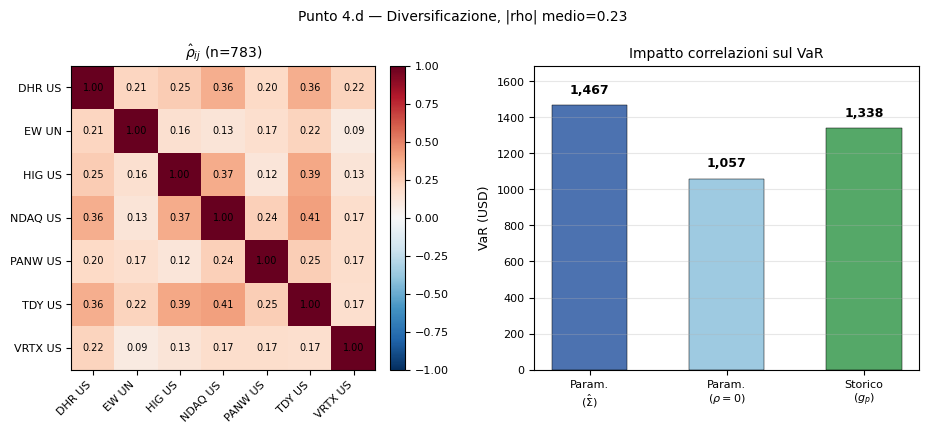

In [9]:
# Punto 4.d - Diversificazione

# Sigma diagonale (rho=0, stesse vol marginali)
Sigma_diag = pd.DataFrame(
    np.diag(np.diag(Sigma_ptf.values)),
    index=Sigma_ptf.index, columns=Sigma_ptf.columns,
)

w = pesi_azioni
x_div = rend_ptf_finestra.dropna(how="any").astype(float)
mu_vec = x_div.mean().values
mu_p_div = float(w @ mu_vec)
sigma_p_div = float(np.sqrt(w @ Sigma_diag.values @ w))
z = float(stats.norm.ppf(ALPHA))
var_g_indip = float(-(mu_p_div + sigma_p_div * z))
var_usd_indip = float(CAPITALE * (1 - np.exp(-var_g_indip)))

# Diversification ratio
sig_i = np.sqrt(np.diag(Sigma_ptf.values))
sigma_undiv = float(np.sum(w * sig_i))
rapporto_div = 1 - sigma_p / sigma_undiv if sigma_undiv > 0 else np.nan

riduzione_usd = var_usd_indip - var_usd_param
riduzione_pct = 100 * riduzione_usd / var_usd_indip if var_usd_indip > 0 else np.nan

# Statistiche correlazioni
coppie_rho = []
cols_c = list(Corr_ptf.columns)
for i in range(len(cols_c)):
    for j in range(i + 1, len(cols_c)):
        coppie_rho.append(float(Corr_ptf.iloc[i, j]))
media_rho = float(np.mean(coppie_rho))
media_abs_rho = float(np.mean(np.abs(coppie_rho)))
max_rho = float(np.max(coppie_rho))
min_rho = float(np.min(coppie_rho))

print("=== Punto 4.d — Diversificazione ===")
print(f"Media |rho|={media_abs_rho:.3f}, max rho={max_rho:.3f}, min rho={min_rho:.3f}")
print(f"sigma_p (full Sigma)={sigma_p:.6f}, sigma_p (diag)={sigma_p_div:.6f}")
print(f"Diversification ratio (1-sigma_p/sum w_i*sigma_i) = {rapporto_div:.4f}")
print(f"VaR param (full Sigma) = {var_usd_param:,.0f} USD")
print(f"VaR param (diag, rho=0) = {var_usd_indip:,.0f} USD")
print(f"Riduzione VaR = {riduzione_usd:,.0f} USD ({riduzione_pct:.1f}%)")
print(f"VaR storico su g_ptf = {var_usd_hist:,.0f} USD")

giudizio = []
if media_abs_rho < 0.45:
    giudizio.append("Correlazioni moderate: buona diversificazione.")
elif media_abs_rho < 0.65:
    giudizio.append("Correlazioni medie: diversificazione parziale.")
else:
    giudizio.append("Correlazioni elevate: diversificazione limitata.")
if riduzione_usd > 0:
    giudizio.append(f"Le correlazioni riducono il VaR di {riduzione_usd:,.0f} USD ({riduzione_pct:.1f}%).")
elif riduzione_usd < 0:
    giudizio.append(f"Le correlazioni positive aumentano il VaR di {abs(riduzione_usd):,.0f} USD rispetto ad asset indipendenti.")
if var_usd_hist > var_usd_param * 1.05:
    giudizio.append("Lo storico e' piu' severo del gaussiano (possibili code pesanti).")
elif var_usd_hist < var_usd_param * 0.95:
    giudizio.append("Lo storico e' meno severo del parametrico su questo campione.")
print("\nGiudizio:")
for l in giudizio:
    print(f"  - {l}")

# Figura: heatmap + barre confronto
fig, (ax_corr, ax_var) = plt.subplots(1, 2, figsize=(9.5, 4.0),
    gridspec_kw={"width_ratios": [1.05, 1.15], "wspace": 0.35})

C4d = Corr_ptf.values
im = ax_corr.imshow(C4d, aspect="equal", cmap="RdBu_r", vmin=-1, vmax=1)
lbl4d = [nome_breve(c) for c in Corr_ptf.columns]
ax_corr.set_xticks(np.arange(len(lbl4d)))
ax_corr.set_yticks(np.arange(len(lbl4d)))
ax_corr.set_xticklabels(lbl4d, rotation=45, ha="right", fontsize=8)
ax_corr.set_yticklabels(lbl4d, fontsize=8)
ax_corr.set_title(f"$\\hat\\rho_{{ij}}$ (n={n_obs_ptf})")
annota_heatmap(ax_corr, C4d, fmt="{:.2f}")
fig.colorbar(im, ax=ax_corr, fraction=0.046, pad=0.04)

etich = ["Param.\n($\\hat\\Sigma$)", "Param.\n($\\rho{=}0$)", "Storico\n($g_p$)"]
valori = [var_usd_param, var_usd_indip, var_usd_hist]
colori = ["#4C72B0", "#9ecae1", "#55A868"]
xd = np.arange(3)
ytop = max(v for v in valori if np.isfinite(v)) * 1.15
barre = ax_var.bar(xd, valori, width=0.55, color=colori, edgecolor="black", linewidth=0.35)
for b, val in zip(barre, valori):
    if np.isfinite(val):
        ax_var.text(b.get_x()+b.get_width()/2, b.get_height()+0.03*ytop,
                    f"{val:,.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax_var.set_xticks(xd)
ax_var.set_xticklabels(etich)
ax_var.set_ylim(0, ytop)
ax_var.set_ylabel("VaR (USD)")
ax_var.set_title("Impatto correlazioni sul VaR")
ax_var.grid(True, axis="y", alpha=0.3)

fig.suptitle(f"Punto 4.d — Diversificazione, |rho| medio={media_abs_rho:.2f}", fontsize=10, y=1.02)
fig.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.32)
salva_fig(fig, "p4d_diversificazione")
plt.show()
plt.close(fig)

=== Punto 4.e — Volatilita costante o dinamica? ===
Vol ann. rolling 1Y: min=13.42%, max=17.59%, media=15.20%, ratio max/min=1.31


,inizio,fine,n,sigma_gg,sigma_ann
periodo,,,,,
P1,2022-11-18,2023-11-16,260,0.008775,0.139299
P2,2023-11-17,2024-11-15,261,0.009455,0.150100
P3,2024-11-18,2025-11-17,261,0.010397,0.165042


,stat,p_value
Bartlett (3 sotto-periodi),7.517056,0.023318
Levene (3 sotto-periodi),0.674818,0.509546
ARCH-LM (lag=10),31.839039,0.000426
Ljung-Box g^2 (lag=5),29.844105,0.000016
Ljung-Box g^2 (lag=10),31.427882,0.000498
Ljung-Box g^2 (lag=20),36.934513,0.011915


Parametri vol condizionata (portafoglio):


,omega,alpha[1],beta[1],nu,persistenza,AIC,BIC,gamma[1]
"GARCH(1,1)-t",0.12320,0.05068,0.8047,4.86215,0.85539,2020.58390,2043.89317,NaN
"EGARCH(1,1,1)-t",-0.01607,0.07508,0.9096,4.90005,NaN,2015.98808,2043.95921,-0.0921



Giudizio:
  - ARCH-LM p=4.26e-04: eteroschedasticita condizionata significativa.
  - Persistenza GARCH alpha+beta=0.855.


[SAVE] /home/user/risk-management/figures/p4e_vol_dinamica.pdf


[SAVE] /home/user/risk-management/figures/p4e_vol_dinamica.png


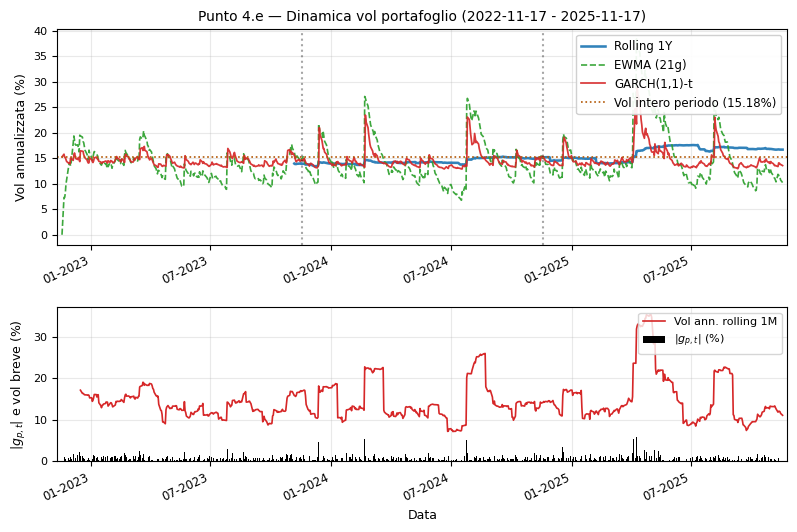

In [10]:
# Punto 4.e --- Dinamica della volatilita del portafoglio

from scipy.stats import bartlett, levene

def test_arch_lm(residui, lag=10):
    e2 = np.asarray(residui, dtype=float) ** 2
    e2 = e2[~np.isnan(e2)]
    n = len(e2)
    if n <= lag + 5:
        return np.nan, np.nan
    y = e2[lag:]
    X = np.ones((n - lag, lag + 1))
    for k in range(1, lag + 1):
        X[:, k] = e2[lag - k : n - k]
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    if ss_tot <= 0:
        return np.nan, np.nan
    r2 = 1 - ss_res / ss_tot
    lm = (n - lag) * r2
    p = 1 - stats.chi2.cdf(lm, df=lag)
    return float(lm), float(p)

def test_ljung_box(x, lag=10):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x = x - x.mean()
    n = len(x)
    if n <= lag + 2:
        return np.nan, np.nan
    var0 = float(np.dot(x, x) / n)
    Q = 0.0
    for k in range(1, lag + 1):
        ck = float(np.dot(x[:n-k], x[k:]) / n)
        rho_k = ck / var0 if var0 > 0 else 0.0
        Q += rho_k ** 2 / max(1, n - k)
    Q *= n * (n + 2)
    p = 1 - stats.chi2.cdf(Q, df=lag)
    return float(Q), float(p)

# Vol rolling 1Y e 1M sul portafoglio
vol_ptf_1Y = g_ptf.rolling(252, min_periods=252).std(ddof=1) * np.sqrt(GG_ANNO)
vol_ptf_1M = g_ptf.rolling(21, min_periods=21).std(ddof=1) * np.sqrt(GG_ANNO)

# EWMA breve
vol_ptf_ewma = vol_ewma_breve(g_ptf, span=21)

# GARCH(1,1)-t e EGARCH sul portafoglio
def stima_vol_ptf(g, scala=100.0):
    gy = g.dropna().astype(float) * scala
    idx = gy.index
    modelli = {}
    parametri = {}

    def prova_fit(modello):
        try:
            return modello.fit(update_freq=0, disp="off", options={"maxiter": 10000})
        except Exception:
            return None

    # GARCH(1,1)-t
    r1 = prova_fit(arch_model(gy, mean="Constant", vol="GARCH", p=1, q=1, dist="studentst"))
    if r1 is not None:
        sigma = pd.Series(r1.conditional_volatility, index=idx) / scala * np.sqrt(GG_ANNO)
        modelli["GARCH(1,1)-t"] = sigma
        p = r1.params.to_dict()
        parametri["GARCH(1,1)-t"] = {
            "omega": p.get("omega"), "alpha[1]": p.get("alpha[1]"),
            "beta[1]": p.get("beta[1]"), "nu": p.get("nu"),
            "persistenza": float(p.get("alpha[1]", 0)) + float(p.get("beta[1]", 0)),
            "AIC": r1.aic, "BIC": r1.bic,
        }

    # EGARCH(1,1,1)-t
    r2 = prova_fit(arch_model(gy, mean="Constant", vol="EGARCH", p=1, o=1, q=1, dist="studentst"))
    if r2 is not None:
        sigma = pd.Series(r2.conditional_volatility, index=idx) / scala * np.sqrt(GG_ANNO)
        modelli["EGARCH(1,1,1)-t"] = sigma
        p = r2.params.to_dict()
        parametri["EGARCH(1,1,1)-t"] = {
            "omega": p.get("omega"), "alpha[1]": p.get("alpha[1]"),
            "gamma[1]": p.get("gamma[1]"), "beta[1]": p.get("beta[1]"),
            "nu": p.get("nu"), "AIC": r2.aic, "BIC": r2.bic,
        }

    return modelli, parametri

modelli_ptf, parametri_ptf = stima_vol_ptf(g_ptf)
param_ptf_df = pd.DataFrame(parametri_ptf).T if parametri_ptf else pd.DataFrame()

# Sotto-periodi
N_SPLIT = 3
bounds = np.linspace(0, len(g_ptf), N_SPLIT + 1, dtype=int)
righe_sub = []
chunks = []
for k in range(N_SPLIT):
    pezzo = g_ptf.iloc[bounds[k]:bounds[k+1]].dropna().astype(float)
    if len(pezzo) > 10:
        chunks.append(pezzo.values)
        righe_sub.append({
            "periodo": f"P{k+1}",
            "inizio": pezzo.index.min().date(),
            "fine": pezzo.index.max().date(),
            "n": len(pezzo),
            "sigma_gg": float(pezzo.std(ddof=1)),
            "sigma_ann": float(pezzo.std(ddof=1) * np.sqrt(GG_ANNO)),
        })
tab_sub = pd.DataFrame(righe_sub).set_index("periodo")

# Test
bart_stat, bart_p = (np.nan, np.nan)
lev_stat, lev_p = (np.nan, np.nan)
if len(chunks) >= 2:
    try:
        bart_stat, bart_p = bartlett(*chunks)
    except Exception:
        pass
    try:
        lev_stat, lev_p = levene(*chunks, center="median")
    except Exception:
        pass

residui = (g_ptf - g_ptf.mean()).dropna().values
arch_stat, arch_p = test_arch_lm(residui, lag=10)
lb_5 = test_ljung_box(residui ** 2, lag=5)
lb_10 = test_ljung_box(residui ** 2, lag=10)
lb_20 = test_ljung_box(residui ** 2, lag=20)

tab_test = pd.DataFrame({
    "stat": [bart_stat, lev_stat, arch_stat, lb_5[0], lb_10[0], lb_20[0]],
    "p_value": [bart_p, lev_p, arch_p, lb_5[1], lb_10[1], lb_20[1]],
}, index=[
    f"Bartlett ({len(chunks)} sotto-periodi)",
    f"Levene ({len(chunks)} sotto-periodi)",
    "ARCH-LM (lag=10)",
    "Ljung-Box g^2 (lag=5)",
    "Ljung-Box g^2 (lag=10)",
    "Ljung-Box g^2 (lag=20)",
])

# Statistiche rolling 1Y
r1y = vol_ptf_1Y.dropna()
vol_min = float(r1y.min()) if not r1y.empty else np.nan
vol_max = float(r1y.max()) if not r1y.empty else np.nan
vol_media = float(r1y.mean()) if not r1y.empty else np.nan
vol_ratio = vol_max / vol_min if vol_min > 0 else np.nan

print("=== Punto 4.e — Volatilita costante o dinamica? ===")
print(f"Vol ann. rolling 1Y: min={vol_min*100:.2f}%, max={vol_max*100:.2f}%, "
      f"media={vol_media*100:.2f}%, ratio max/min={vol_ratio:.2f}")
display(tab_sub.round(6))
display(tab_test.round(6))
if not param_ptf_df.empty:
    print("Parametri vol condizionata (portafoglio):")
    display(param_ptf_df.round(5))

# Giudizio
giudizio_e = []
if vol_ratio > 1.5:
    giudizio_e.append(f"Vol rolling 1Y varia x{vol_ratio:.2f}: non costante.")
if np.isfinite(arch_p) and arch_p < 0.05:
    giudizio_e.append(f"ARCH-LM p={arch_p:.2e}: eteroschedasticita condizionata significativa.")
elif np.isfinite(arch_p):
    giudizio_e.append(f"ARCH-LM p={arch_p:.3f}: non si rifiuta H0 (vol costante).")
if np.isfinite(lev_p) and lev_p < 0.05:
    giudizio_e.append(f"Levene p={lev_p:.3f}: varianze inter-periodo diverse.")
if "GARCH(1,1)-t" in parametri_ptf:
    ab = parametri_ptf["GARCH(1,1)-t"].get("persistenza", np.nan)
    if np.isfinite(ab) and ab > 0.95:
        giudizio_e.append(f"Persistenza GARCH alpha+beta={ab:.3f}: shock molto persistenti.")
    elif np.isfinite(ab):
        giudizio_e.append(f"Persistenza GARCH alpha+beta={ab:.3f}.")
print("\nGiudizio:")
for l in giudizio_e:
    print(f"  - {l}")

# Figura: 2 pannelli
fig, (ax_v, ax_p) = plt.subplots(2, 1, figsize=(8.2, 6.0), sharex=False,
    gridspec_kw={"height_ratios": [1.4, 1.0], "hspace": 0.34})

if not vol_ptf_1Y.dropna().empty:
    ax_v.plot(vol_ptf_1Y.index, vol_ptf_1Y.values * 100, color="#1f77b4",
              linewidth=1.85, alpha=0.92, label="Rolling 1Y")
if not vol_ptf_ewma.dropna().empty:
    ax_v.plot(vol_ptf_ewma.index, vol_ptf_ewma.values * 100, color="#2ca02c",
              linewidth=1.2, linestyle="--", alpha=0.92, label="EWMA (21g)")
garch_ptf_1 = modelli_ptf.get("GARCH(1,1)-t")
if garch_ptf_1 is not None:
    ax_v.plot(garch_ptf_1.dropna().index, garch_ptf_1.dropna().values * 100,
              color="#d62728", linewidth=1.25, alpha=0.92, label="GARCH(1,1)-t")
ax_v.axhline(sigma_ptf_ann * 100, color="#b35806", linestyle=":", linewidth=1.2,
             label=f"Vol intero periodo ({sigma_ptf_ann*100:.2f}%)")

for k in range(1, N_SPLIT):
    idx_b = bounds[k]
    if 0 < idx_b < len(g_ptf):
        ax_v.axvline(g_ptf.index[idx_b], color="black", linestyle=":", alpha=0.35)

ax_v.set_ylabel("Vol annualizzata (%)")
ax_v.set_title(f"Punto 4.e — Dinamica vol portafoglio ({t0_ptf.date()} - {t_fine_ptf.date()})")
ax_v.grid(True, alpha=0.28)
ax_v.legend(loc="upper right", fontsize=8.5, framealpha=0.92)

abs_g = g_ptf.abs() * 100
ax_p.bar(abs_g.index, abs_g.values, color="black", width=1.0, alpha=1, label="$|g_{p,t}|$ (%)")
if not vol_ptf_1M.dropna().empty:
    ax_p.plot(vol_ptf_1M.index, vol_ptf_1M.values * 100, color="#d62728",
              linewidth=1.2, label="Vol ann. rolling 1M")
ax_p.set_ylabel("$|g_{p,t}|$ e vol breve (%)")
ax_p.set_xlabel("Data")
ax_p.grid(True, alpha=0.28)
ax_p.legend(loc="upper right", fontsize=8)

fig.subplots_adjust(left=0.08, right=0.97, top=0.86, bottom=0.14, hspace=0.50)
formatta_assi((ax_v, ax_p), g_ptf.index, fontsize=8.5)
salva_fig(fig, "p4e_vol_dinamica")
plt.show()
plt.close(fig)

In [11]:
# Check finali

print("=== Check finali ===")

# Pesi
s_pesi = pesi_azioni.sum() + PESO_CASH
assert np.isclose(s_pesi, 1.0), f"Pesi non sommano a 1: {s_pesi}"
print(f"Pesi: somma={s_pesi:.4f} OK")

# VaR parametrico spot-check (primo titolo)
g0 = rend_log.iloc[:, 0].dropna()
z_alpha = stats.norm.ppf(ALPHA)
var_ref = -(float(g0.mean()) + float(g0.std(ddof=1)) * z_alpha)
var_calc = float(tabella_var.iloc[0, 0])
assert abs(var_ref - var_calc) < 1e-8, f"VaR parametrico non coerente: {var_ref} vs {var_calc}"
print(f"VaR parametrico primo titolo: {var_ref:.8f} == {var_calc:.8f} OK")

# VaR portafoglio MC vs parametrico
if np.isfinite(var_g_param) and np.isfinite(var_g_mc) and var_g_param > 0:
    diff_rel = abs(var_g_param - var_g_mc) / var_g_param
    print(f"VaR ptf param={var_g_param:.6f}, MC={var_g_mc:.6f}, diff={diff_rel:.2%}")
    if diff_rel > 0.08:
        print("  ATTENZIONE: MC discosta >8% dal parametrico")
    else:
        print("  OK (entro 8%)")

# Figure generate
if SALVA_FIG and os.path.isdir(CARTELLA_FIG):
    nomi_attesi = [
        "p1_prezzi_normalizzati",
        "p1_rendimenti_log",
        "p2_rendimenti",
        "p2_vol_statica_vs_roll1y",
        "p2_heatmap_rho",
        "p2_heatmap_pval",
        "p2_vol_pannelli",
        "p3_var_e_violazioni",
        "p4a_portafoglio",
        "p4b_rendimenti_vol",
        "p4c_var_ptf",
        "p4d_diversificazione",
        "p4e_vol_dinamica",
    ]
    print(f"\nFigure in {os.path.abspath(CARTELLA_FIG)}:")
    for nome in nomi_attesi:
        ok = os.path.isfile(os.path.join(CARTELLA_FIG, nome + ".pdf"))
        print(f"  [{'OK' if ok else '--'}] {nome}")

print("\nNotebook completato.")

=== Check finali ===
Pesi: somma=1.0000 OK
VaR parametrico primo titolo: 0.02884714 == 0.02884714 OK
VaR ptf param=0.014779, MC=0.014718, diff=0.41%
  OK (entro 8%)

Figure in /home/user/risk-management/figures:
  [OK] p1_prezzi_normalizzati
  [OK] p1_rendimenti_log
  [OK] p2_rendimenti
  [OK] p2_vol_statica_vs_roll1y
  [OK] p2_heatmap_rho
  [OK] p2_heatmap_pval
  [OK] p2_vol_pannelli
  [OK] p3_var_e_violazioni
  [OK] p4a_portafoglio
  [OK] p4b_rendimenti_vol
  [OK] p4c_var_ptf
  [OK] p4d_diversificazione
  [OK] p4e_vol_dinamica

Notebook completato.
